# NB19 — Linear Regression for Time Series

> **StatQuest: "Time-series data has structure — trend, seasonality, momentum. Linear regression can capture all three if you engineer the right features."**

---

## The main ideas:

1. Standard OLS assumes independence — time series violates this (autocorrelation)
2. Feature engineering turns time series structure into regression features:
   - **Trend:** add `t` (index) as a numeric feature
   - **Seasonality:** add `sin(2*pi*t/period)` and `cos(2*pi*t/period)` — Fourier features
   - **Momentum/AR:** add `y_{t-1}, y_{t-2}, ...` as lag features
3. Check residual ACF to see if structure remains unexplained


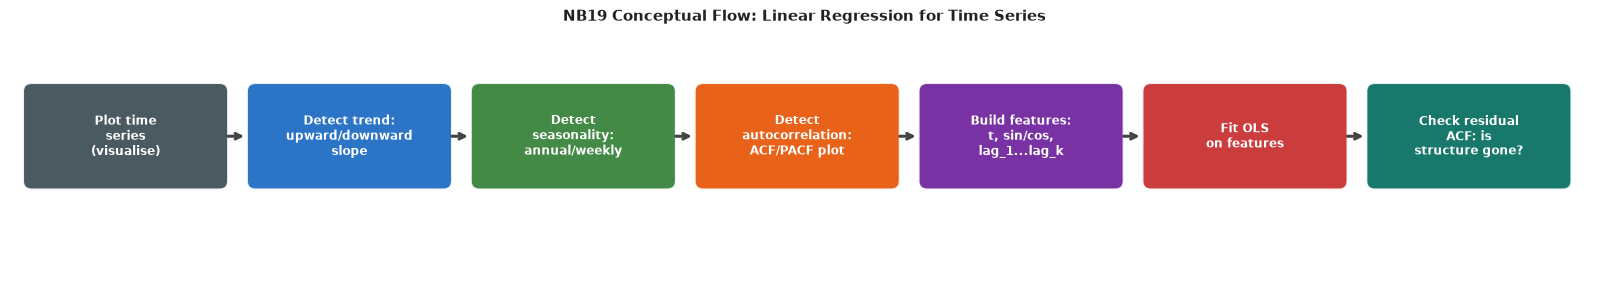

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def flow_diagram(steps, title, colors=None, notes=None, figsize=(14, 2.8)):
    n = len(steps)
    default_colors = ['#1565C0','#2E7D32','#E65100','#6A1B9A',
                      '#00695C','#AD1457','#37474F','#4E342E',
                      '#0277BD','#558B2F','#C62828','#F57F17']
    colors = (colors or default_colors)[:n]
    notes  = notes or ['']*n
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.3, n*3.1); ax.set_ylim(-1.2, 2.4); ax.axis('off')
    bw, bh = 2.6, 1.3
    for i,(step,color,note) in enumerate(zip(steps,colors,notes)):
        x = i*3.1
        box = FancyBboxPatch((x,0.2),bw,bh,boxstyle="round,pad=0.12",
                             facecolor=color,edgecolor='white',linewidth=1.5,alpha=0.90)
        ax.add_patch(box)
        ax.text(x+bw/2,0.2+bh/2,step,ha='center',va='center',fontsize=8.5,
                color='white',fontweight='bold',multialignment='center')
        if note:
            ax.text(x+bw/2,0.02,note,ha='center',va='top',fontsize=7,
                    color='#555',style='italic')
        if i < n-1:
            ax.annotate('',xy=(x+bw+0.38,0.2+bh/2),xytext=(x+bw+0.08,0.2+bh/2),
                       arrowprops=dict(arrowstyle='->',color='#444',lw=2.2))
    ax.set_title(title,fontsize=11,fontweight='bold',pad=6,color='#222')
    plt.tight_layout(pad=0.4); plt.show()

flow_diagram(
    steps=[
        'Plot time\nseries\n(visualise)',
        'Detect trend:\nupward/downward\nslope',
        'Detect\nseasonality:\nannual/weekly',
        'Detect\nautocorrelation:\nACF/PACF plot',
        'Build features:\nt, sin/cos,\nlag_1...lag_k',
        'Fit OLS\non features',
        'Check residual\nACF: is\nstructure gone?',
    ],
    title='NB19 Conceptual Flow: Linear Regression for Time Series',
    colors=['#37474F','#1565C0','#2E7D32','#E65100','#6A1B9A','#C62828','#00695C'],
    figsize=(16, 2.8),
)


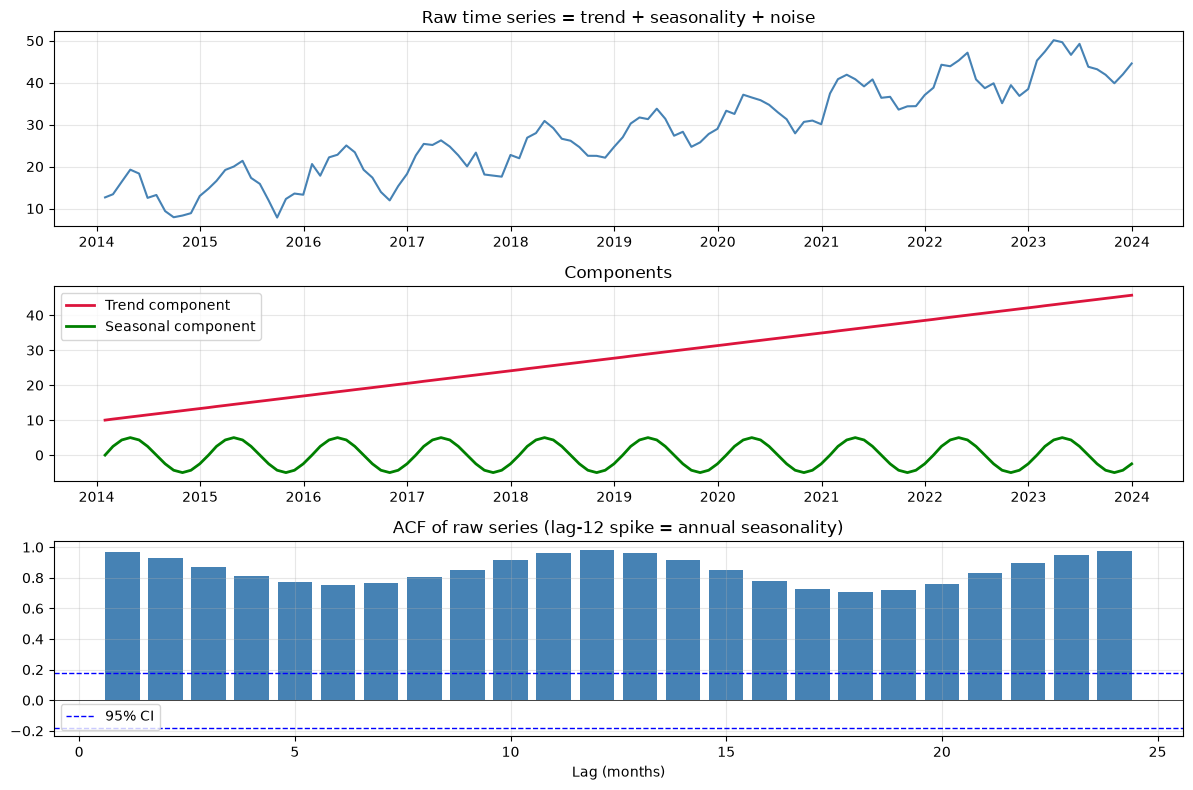

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
n    = 120   # 10 years of monthly data
t    = np.arange(n)
trend    = 0.3*t
seasonal = 5*np.sin(2*np.pi*t/12)
noise    = np.random.normal(0, 1.5, n)
y = 10 + trend + seasonal + noise

dates = pd.date_range('2014-01', periods=n, freq='ME')

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(dates, y, linewidth=1.5, color='steelblue')
axes[0].set_title('Raw time series = trend + seasonality + noise'); axes[0].grid(alpha=0.3)

axes[1].plot(dates, trend + 10, color='crimson', linewidth=2, label='Trend component')
axes[1].plot(dates, seasonal,   color='green',   linewidth=2, label='Seasonal component')
axes[1].legend(); axes[1].set_title('Components'); axes[1].grid(alpha=0.3)

import statsmodels.api as sm
acf_vals = [np.corrcoef(y[:-lag], y[lag:])[0,1] for lag in range(1,25)]
axes[2].bar(range(1,25), acf_vals, color='steelblue')
axes[2].axhline(1.96/n**0.5,  color='blue', linestyle='--', linewidth=1, label='95% CI')
axes[2].axhline(-1.96/n**0.5, color='blue', linestyle='--', linewidth=1)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('ACF of raw series (lag-12 spike = annual seasonality)')
axes[2].set_xlabel('Lag (months)'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()


Trend+Fourier     R^2 = 0.9804
Trend+Fourier+Lag R^2 = 0.9805


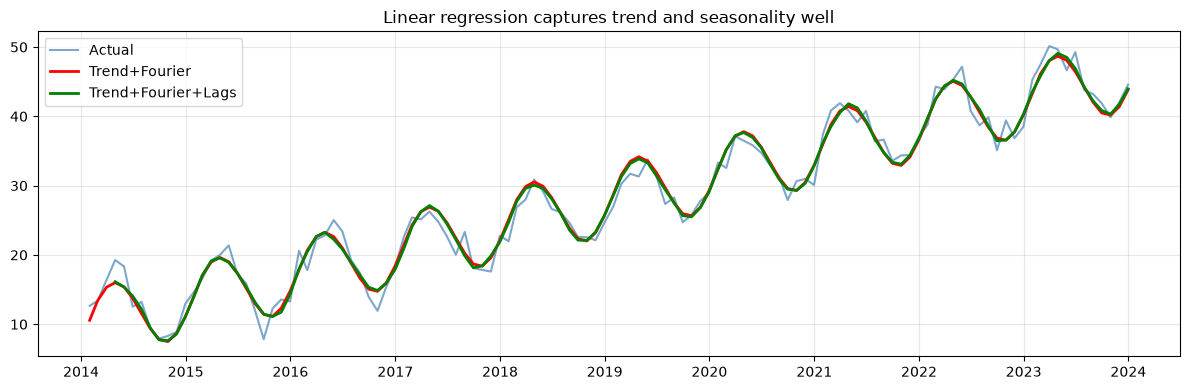

In [3]:
import numpy as np, pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def make_features(t, n_fourier=2, period=12, lags=[1,2,3]):
    df = pd.DataFrame({'t': t.astype(float)})
    for k in range(1, n_fourier+1):
        df[f'sin_{k}'] = np.sin(2*np.pi*k*t/period)
        df[f'cos_{k}'] = np.cos(2*np.pi*k*t/period)
    if lags:
        df['y'] = y   # temporary for lagging
        for lag in lags:
            df[f'lag_{lag}'] = df['y'].shift(lag)
        df = df.drop(columns='y').dropna()
    return df

# Model 1: trend + Fourier only
X_tf = make_features(t, n_fourier=2, lags=[])
m1   = LinearRegression().fit(X_tf, y)
y_hat1 = m1.predict(X_tf)
print(f"Trend+Fourier     R^2 = {r2_score(y, y_hat1):.4f}")

# Model 2: trend + Fourier + lags
X_tfl = make_features(t, n_fourier=2, lags=[1,2,3])
y_lag = y[len(y)-len(X_tfl):]
m2    = LinearRegression().fit(X_tfl, y_lag)
y_hat2 = m2.predict(X_tfl)
print(f"Trend+Fourier+Lag R^2 = {r2_score(y_lag, y_hat2):.4f}")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, y, color='steelblue', linewidth=1.5, alpha=0.7, label='Actual')
ax.plot(dates, y_hat1, 'r-', linewidth=2, label=f'Trend+Fourier')
ax.plot(dates[len(y)-len(y_hat2):], y_hat2, 'g-', linewidth=2, label=f'Trend+Fourier+Lags')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Linear regression captures trend and seasonality well')
plt.tight_layout(); plt.show()


## Key Takeaways

| Feature type | Captures | Formula |
|-------------|---------|---------|
| t (index) | Linear trend | t = 0, 1, 2, ... |
| sin/cos | Fixed-period seasonality | sin(2*pi*k*t/period) |
| Lag y_{t-k} | Autocorrelation/momentum | y value k steps ago |
| Residual ACF | Unexplained structure | Should be within CI bands |

**Caution:** with lag features, observations are NOT independent -> t-tests technically invalid.
Use this for forecasting, not causal inference.

**Next: NB20 — Sklearn Pipelines: the production-ready workflow.**
